In [3]:
import pandas as pd

df = pd.read_csv("agriculture_yield_dataset.csv")

print("Rows and Columns:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nFirst 10 Records:")
print(df.head(10))

Rows and Columns: (1500, 8)

Column Names:
Index(['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'irrigation_hours',
       'soil_ph', 'crop_type', 'soil_type', 'yield_ton_per_hectare'],
      dtype='object')

First 10 Records:
   rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  soil_ph  \
0        588.6           18.6          242.4               6.5      6.5   
1        772.8           34.6          247.2              10.0      6.5   
2        970.9           36.3          168.4               7.3      6.4   
3        611.7           19.0          121.7               3.7      6.0   
4        696.1           29.6          184.6               5.1      6.1   
5        831.9           28.0          190.3               2.1      6.1   
6       1023.8           32.0          108.5               6.9      6.2   
7       1142.4           18.4          241.9               4.1      7.3   
8        810.4           36.4          164.8               9.9      6.5   
9       1085.5      

In [4]:
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

rainfall_mm              float64
temperature_c            float64
fertilizer_kg            float64
irrigation_hours         float64
soil_ph                  float64
crop_type                 object
soil_type                 object
yield_ton_per_hectare    float64
dtype: object

Missing Values:
rainfall_mm              0
temperature_c            0
fertilizer_kg            0
irrigation_hours         0
soil_ph                  0
crop_type                0
soil_type                0
yield_ton_per_hectare    0
dtype: int64


In [6]:
print(df.describe())

print("\nMean Values:")
print(df.mean(numeric_only=True))

print("\nStandard Deviations:")
print(df.std(numeric_only=True))

       rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  \
count  1500.000000    1500.000000    1500.000000       1500.000000   
mean    754.054667      27.749467     148.744067          5.403267   
std     255.097216       5.758101      56.990279          2.584329   
min     300.200000      18.000000      50.300000          1.000000   
25%     536.175000      22.600000      98.600000          3.200000   
50%     761.200000      27.700000     146.850000          5.400000   
75%     964.375000      32.600000     196.575000          7.600000   
max    1200.000000      38.000000     249.900000         10.000000   

           soil_ph  yield_ton_per_hectare  
count  1500.000000            1500.000000  
mean      6.759133               5.028793  
std       0.719742               0.968282  
min       5.500000               2.090000  
25%       6.100000               4.337500  
50%       6.800000               5.010000  
75%       7.400000               5.740000  
max       8.00000

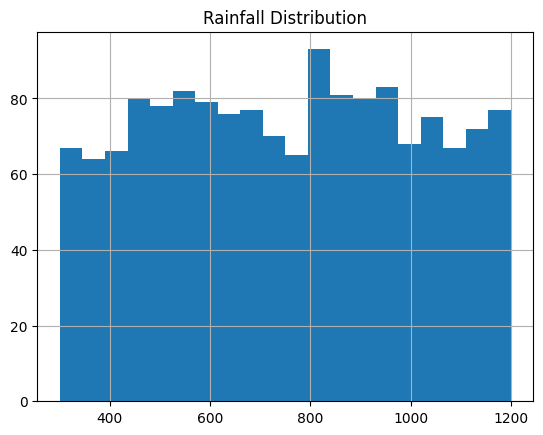

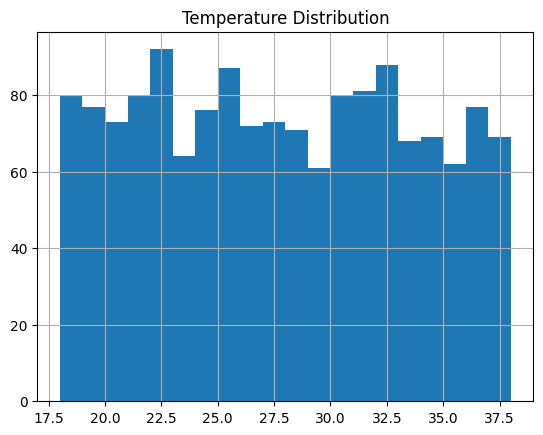

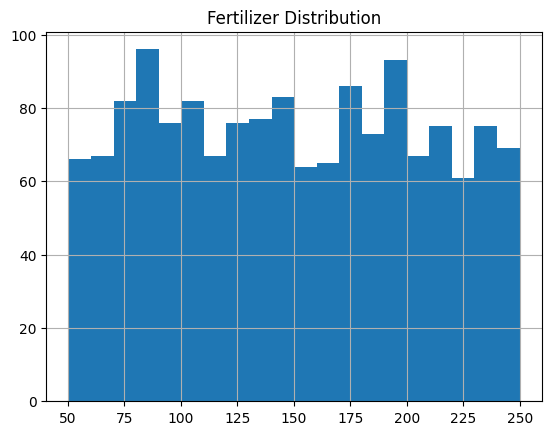

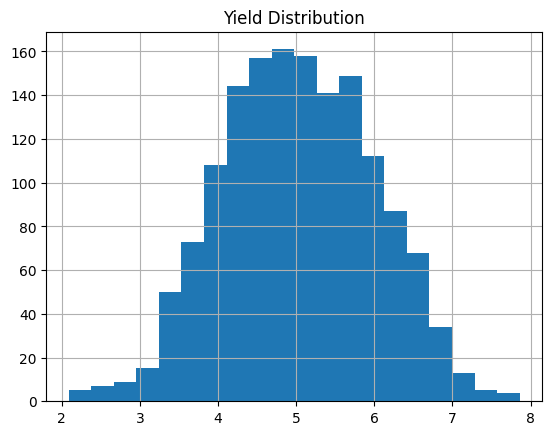

In [7]:
import matplotlib.pyplot as plt

df["rainfall_mm"].hist(bins=20)
plt.title("Rainfall Distribution")
plt.show()

df["temperature_c"].hist(bins=20)
plt.title("Temperature Distribution")
plt.show()

df["fertilizer_kg"].hist(bins=20)
plt.title("Fertilizer Distribution")
plt.show()

df["yield_ton_per_hectare"].hist(bins=20)
plt.title("Yield Distribution")
plt.show()

crop_type
Cotton     311
Soybean    306
Wheat      303
Rice       293
Maize      287
Name: count, dtype: int64


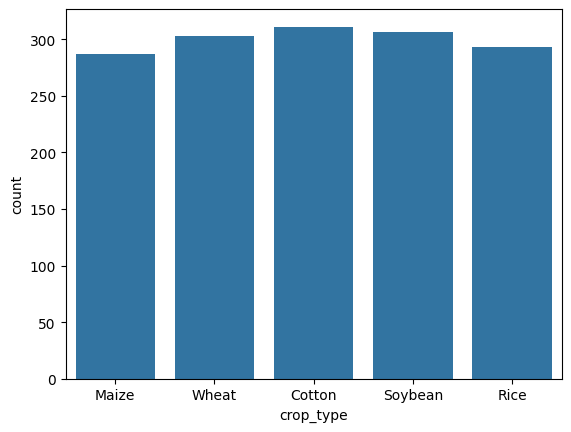

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

print(df["crop_type"].value_counts())

sns.countplot(x="crop_type", data=df)
plt.show()

soil_type
Clay     534
Sandy    492
Loamy    474
Name: count, dtype: int64


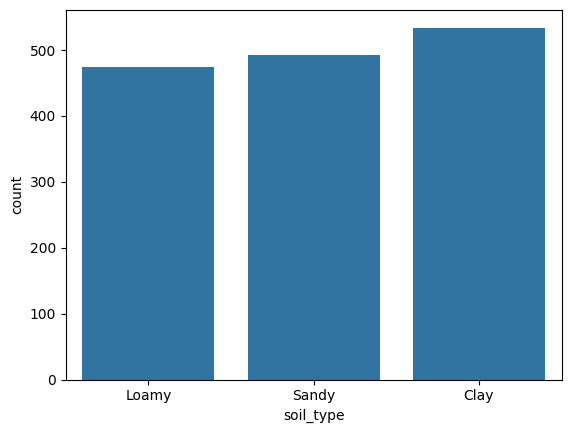

In [9]:
print(df["soil_type"].value_counts())

sns.countplot(x="soil_type", data=df)
plt.show()

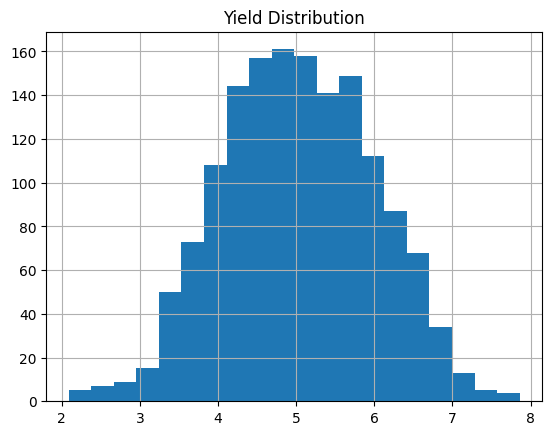

In [10]:
df["yield_ton_per_hectare"].hist(bins=20)
plt.title("Yield Distribution")
plt.show()

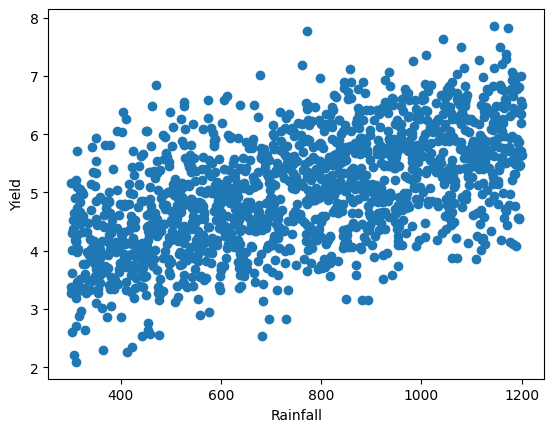

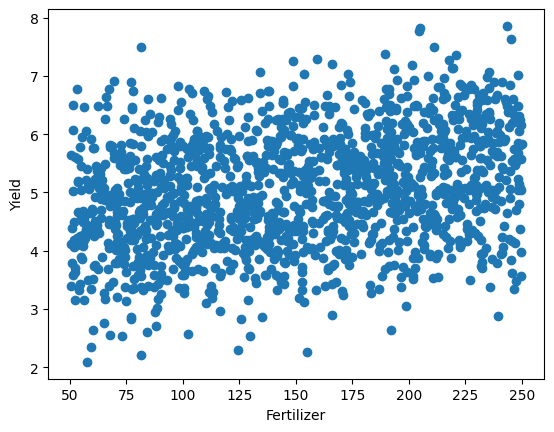

In [11]:
plt.scatter(df["rainfall_mm"], df["yield_ton_per_hectare"])
plt.xlabel("Rainfall")
plt.ylabel("Yield")
plt.show()

plt.scatter(df["fertilizer_kg"], df["yield_ton_per_hectare"])
plt.xlabel("Fertilizer")
plt.ylabel("Yield")
plt.show()

                       rainfall_mm  temperature_c  fertilizer_kg  \
rainfall_mm               1.000000       0.026721       0.002558   
temperature_c             0.026721       1.000000       0.037468   
fertilizer_kg             0.002558       0.037468       1.000000   
irrigation_hours          0.010877       0.007114      -0.010497   
soil_ph                   0.006916       0.001513       0.010001   
yield_ton_per_hectare     0.553704      -0.022559       0.278043   

                       irrigation_hours   soil_ph  yield_ton_per_hectare  
rainfall_mm                    0.010877  0.006916               0.553704  
temperature_c                  0.007114  0.001513              -0.022559  
fertilizer_kg                 -0.010497  0.010001               0.278043  
irrigation_hours               1.000000  0.009307               0.542664  
soil_ph                        0.009307  1.000000               0.024412  
yield_ton_per_hectare          0.542664  0.024412               1.000000 

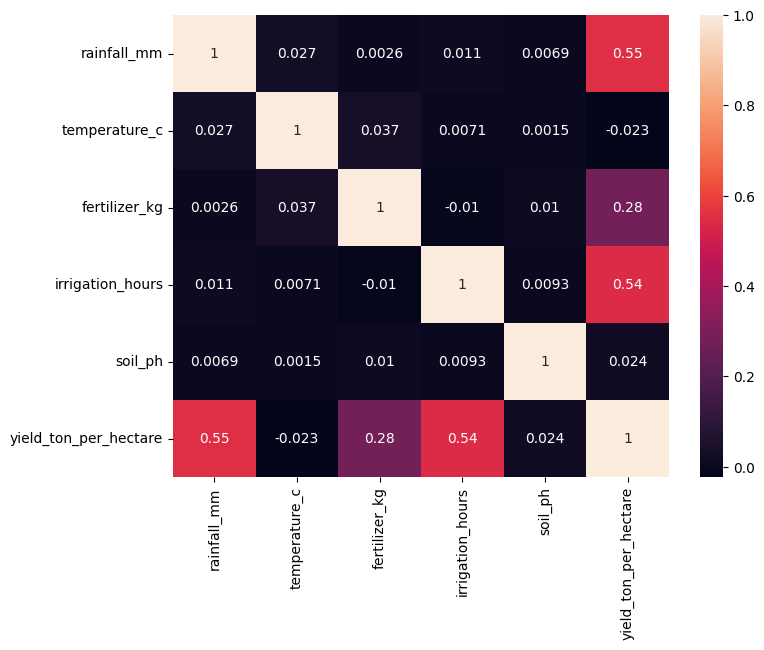

In [12]:
import seaborn as sns

corr_matrix = df.corr(numeric_only=True)

print(corr_matrix)

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True)
plt.show()

In [13]:
crop_avg = df.groupby("crop_type")["yield_ton_per_hectare"].mean()
print(crop_avg)

soil_avg = df.groupby("soil_type")["yield_ton_per_hectare"].mean()
print(soil_avg)

crop_type
Cotton     4.607299
Maize      4.897143
Rice       5.494744
Soybean    5.173431
Wheat      4.989472
Name: yield_ton_per_hectare, dtype: float64
soil_type
Clay     5.134326
Loamy    5.366519
Sandy    4.588882
Name: yield_ton_per_hectare, dtype: float64


In [14]:
categorical_columns = ["crop_type", "soil_type"]

encoded_df = pd.get_dummies(df, columns=categorical_columns)

print(encoded_df.head())

   rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  soil_ph  \
0        588.6           18.6          242.4               6.5      6.5   
1        772.8           34.6          247.2              10.0      6.5   
2        970.9           36.3          168.4               7.3      6.4   
3        611.7           19.0          121.7               3.7      6.0   
4        696.1           29.6          184.6               5.1      6.1   

   yield_ton_per_hectare  crop_type_Cotton  crop_type_Maize  crop_type_Rice  \
0                   5.92             False             True           False   
1                   6.24             False             True           False   
2                   4.77             False            False           False   
3                   4.04             False             True           False   
4                   5.17              True            False           False   

   crop_type_Soybean  crop_type_Wheat  soil_type_Clay  soil_type_Loamy  \


In [15]:
X = encoded_df.drop("yield_ton_per_hectare", axis=1)
y = encoded_df["yield_ton_per_hectare"]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (1500, 13)
y Shape: (1500,)


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (1200, 13)
X_test : (300, 13)
y_train: (1200,)
y_test : (300,)


In [17]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

model.fit(X_train, y_train)

print("Intercept:")
print(model.intercept_)

coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print(coef_df)

Intercept:
1.9111026182800726
              Feature  Coefficient
0         rainfall_mm     0.002035
1       temperature_c    -0.009175
2       fertilizer_kg     0.004978
3    irrigation_hours     0.198327
4             soil_ph     0.004901
5    crop_type_Cotton    -0.386623
6     crop_type_Maize    -0.147693
7      crop_type_Rice     0.477369
8   crop_type_Soybean     0.095096
9     crop_type_Wheat    -0.038149
10     soil_type_Clay     0.062653
11    soil_type_Loamy     0.365627
12    soil_type_Sandy    -0.428280
